# Laboratorio 06 - Mineria de Datos

## k-NN y regresion logistica

| Campo | Detalle |
|---|---|
| Estudiante | Jhadir Chahua Yupanqui |
| Curso | Mineria de Datos |
| Semana | 06 |
| Tema | k-NN y regresion logistica |
| Dataset / caso | Heart Disease UCI |
| Docente | Pilar Rocio Sayan Mejia |
| Periodo | 2026-I |
---


---
# ACTIVIDAD 1: Revisión de Conceptos — k-NN y Regresión Logística

Complete la tabla con **definiciones propias**. No copie textualmente de los materiales.

| N° | Concepto | Definición |
|:---:|---|---|
| 1 | k-Nearest Neighbors (k-NN) | |
| 2 | Lazy learner vs. Eager learner | |
| 3 | Valor de k en k-NN | |
| 4 | Efecto de k pequeño vs. k grande | |
| 5 | ¿Por qué normalizar antes de k-NN? | |
| 6 | Regresión logística (qué predice) | |
| 7 | Función sigmoide | |
| 8 | Coeficientes de regresión logística | |
| 9 | Odds ratio (interpretación) | |
| 10 | Regularización L1 (Lasso) vs. L2 (Ridge) | |
| 11 | Diferencia principal entre k-NN y Reg. Logística | |
| 12 | ¿Cuándo elegirías k-NN sobre Reg. Logística? | |

---
# ACTIVIDAD 2: Desarrollo Práctico — Clasificación con k-NN y Regresión Logística

En esta actividad aplicarás los dos primeros algoritmos de clasificación del curso al dataset **Heart Disease (UCI)**.
Seguirás el pipeline completo: carga → exploración → preparación → modelado → evaluación → comparación.

> *Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 10.*

---
## 🔹 Paso 1: Carga y exploración del dataset Heart Disease

### ¿Qué haremos?
Cargaremos el dataset y entenderemos su estructura. Este paso es equivalente a las **Fases 1 y 2 de CRISP-DM** (comprensión del negocio y de los datos).

### ¿Por qué es importante?
Antes de aplicar cualquier algoritmo, debemos conocer los datos: cuántos registros hay, si existen valores nulos, y cómo está distribuida la variable objetivo.

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

In [10]:
# Nota personal: se mantiene la base del laboratorio S06 y se documentan los pasos clave.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, f1_score, roc_auc_score, precision_score,
                             recall_score, classification_report, confusion_matrix, roc_curve)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

# ==========================================
# CARGAR DATASET HEART DISEASE (UCI)
# ==========================================
url = 'https://raw.githubusercontent.com/sharmaroshan/Heart-UCI-Dataset/master/heart.csv'
df = pd.read_csv(url)

print('=' * 60)
print('DATASET: HEART DISEASE (UCI)')
print('=' * 60)
print(f'Dimensiones: {df.shape[0]} pacientes × {df.shape[1]} variables')
print(f'Valores nulos totales: {df.isnull().sum().sum()}')
print(f'\nVariable objetivo (target):')
print(df['target'].value_counts())
print(f'\n  0 = Sin enfermedad: {(df["target"]==0).sum()} ({(df["target"]==0).mean()*100:.1f}%)')
print(f'  1 = Con enfermedad: {(df["target"]==1).sum()} ({(df["target"]==1).mean()*100:.1f}%)')
print(f'\nPrimeras filas:')
df.head()

DATASET: HEART DISEASE (UCI)
Dimensiones: 303 pacientes × 14 variables
Valores nulos totales: 0

Variable objetivo (target):
target
1    165
0    138
Name: count, dtype: int64

  0 = Sin enfermedad: 138 (45.5%)
  1 = Con enfermedad: 165 (54.5%)

Primeras filas:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


### 📌 Diccionario de variables clínicas
Es fundamental entender qué mide cada variable antes de modelar. Aquí tienes la descripción clínica:

| Variable | Descripción clínica | Tipo |
|---|---|---|
| `age` | Edad del paciente en años | Continua |
| `sex` | Sexo biológico (1=masculino, 0=femenino) | Binaria |
| `cp` | Tipo de dolor torácico: 0=asintomático, 1=angina típica, 2=angina atípica, 3=no anginoso | Categórica ordinal |
| `trestbps` | Presión arterial en reposo (mm Hg) — valores normales: 90–120 | Continua |
| `chol` | Colesterol sérico (mg/dl) — valores normales: <200 | Continua |
| `fbs` | Glucemia en ayunas > 120 mg/dl (1=sí, 0=no) — indicador de diabetes | Binaria |
| `restecg` | Resultado del electrocardiograma en reposo (0=normal, 1=anormalidad ST-T, 2=hipertrofia ventricular) | Categórica |
| `thalach` | Frecuencia cardíaca máxima alcanzada durante prueba de esfuerzo | Continua |
| `exang` | Angina inducida por ejercicio (1=sí, 0=no) — dolor en el pecho al hacer ejercicio | Binaria |
| `oldpeak` | Depresión del segmento ST inducida por ejercicio — mide daño cardíaco | Continua |
| `slope` | Pendiente del segmento ST durante ejercicio (0=descendente, 1=plano, 2=ascendente) | Categórica |
| `ca` | Número de vasos principales coloreados por fluoroscopía (0–4) | Discreta |
| `thal` | Tipo de talasemia: 0=normal, 1=defecto fijo, 2=defecto reversible, 3=talasemia | Categórica |

### Pregunta 1
**¿Cuántos pacientes tiene el dataset? ¿Está balanceado (proporción de enfermos vs. sanos)? ¿Cómo se compara con el desbalance del dataset Telco Churn de semanas anteriores (~26.5% churn)?**

**Respuesta:** El dataset tiene **303 pacientes** y **14 variables**. La variable objetivo está bastante balanceada: **165 pacientes enfermos (54.5%)** y **138 pacientes sanos (45.5%)**. Comparado con Telco Churn, este dataset está mucho menos desbalanceado, porque en Telco solo aproximadamente **26.5%** eran churners y la clase mayoritaria dominaba más el entrenamiento.


---
## 🔹 Paso 2: Análisis exploratorio — Correlaciones clínicas

### ¿Qué haremos?
Calcularemos la correlación de cada variable con la enfermedad cardíaca para identificar los **factores de riesgo más relevantes**.

### ¿Por qué?
La correlación nos da una primera pista de qué variables podrían ser útiles para el modelo. Sin embargo, correlación NO implica causalidad: una variable con alta correlación no necesariamente *causa* la enfermedad.

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 4.*

ESTADÍSTICAS DESCRIPTIVAS:
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00   
mean    54.37    0.68    0.97    131.62  246.26    0.15     0.53   149.65   
std      9.08    0.47    1.03     17.54   51.83    0.36     0.53    22.91   
min     29.00    0.00    0.00     94.00  126.00    0.00     0.00    71.00   
25%     47.50    0.00    0.00    120.00  211.00    0.00     0.00   133.50   
50%     55.00    1.00    1.00    130.00  240.00    0.00     1.00   153.00   
75%     61.00    1.00    2.00    140.00  274.50    0.00     1.00   166.00   
max     77.00    1.00    3.00    200.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  target  
count  303.00   303.00  303.00  303.00  303.00  303.00  
mean     0.33     1.04    1.40    0.73    2.31    0.54  
std      0.47     1.16    0.62    1.02    0.61    0.50  
min      0.00     0.00    0.00    0.00    0.00    0

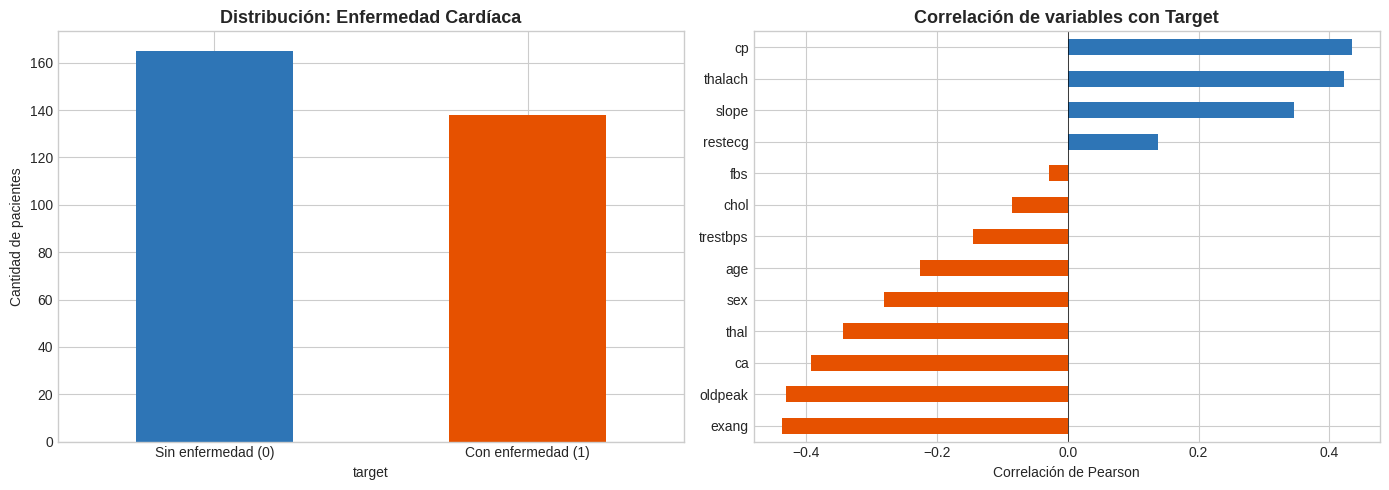


INTERPRETACIÓN DE CORRELACIONES:
  Correlación positiva (+) → a mayor valor, mayor riesgo de enfermedad
  Correlación negativa (−) → a mayor valor, menor riesgo de enfermedad

TOP 5 factores más correlacionados:
  exang         r = -0.437  → ↓ riesgo
  cp            r = +0.434  → ↑ riesgo
  oldpeak       r = -0.431  → ↓ riesgo
  thalach       r = +0.422  → ↑ riesgo
  ca            r = -0.392  → ↓ riesgo


In [19]:
# Estadísticas descriptivas
print('ESTADÍSTICAS DESCRIPTIVAS:')
print(df.describe().round(2))

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de target
df['target'].value_counts().plot(kind='bar', color=['#2E75B6', '#E65100'], ax=axes[0])
axes[0].set_title('Distribución: Enfermedad Cardíaca', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(['Sin enfermedad (0)', 'Con enfermedad (1)'], rotation=0)
axes[0].set_ylabel('Cantidad de pacientes')

# Gráfico 2: Correlación con target
correlations = df.corr()['target'].drop('target').sort_values()
colors_corr = ['#E65100' if v < 0 else '#2E75B6' for v in correlations]
correlations.plot(kind='barh', color=colors_corr, ax=axes[1])
axes[1].set_title('Correlación de variables con Target', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Correlación de Pearson')
axes[1].axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

# Interpretación automática
print('\nINTERPRETACIÓN DE CORRELACIONES:')
print('  Correlación positiva (+) → a mayor valor, mayor riesgo de enfermedad')
print('  Correlación negativa (−) → a mayor valor, menor riesgo de enfermedad')
print('\nTOP 5 factores más correlacionados:')
top_corr = correlations.abs().sort_values(ascending=False).head(5)
for var, val in top_corr.items():
    signo = '↑ riesgo' if correlations[var] > 0 else '↓ riesgo'
    print(f'  {var:12s}  r = {correlations[var]:+.3f}  → {signo}')

### Pregunta 2
**¿Cuáles son las 3 variables con mayor correlación (positiva o negativa) con la enfermedad? ¿Tienen sentido clínico? Por ejemplo, ¿es lógico que `thalach` (frecuencia cardíaca máxima) tenga correlación positiva con la enfermedad?**

**Respuesta:** Las variables con mayor correlación absoluta fueron **`exang` (-0.437)**, **`cp` (+0.434)** y **`oldpeak` (-0.431)**. También aparece `thalach` con correlación positiva importante (**+0.422**). Estos resultados deben interpretarse con cuidado porque varias variables están codificadas por categorías clínicas. En este dataset, `cp` y `thalach` aparecen asociadas positivamente con `target=1`, mientras que `exang`, `oldpeak` y `ca` aparecen con relación negativa. Clínicamente no basta mirar el signo aislado: hay que revisar la codificación y contrastar con criterio médico.


---
## 🔹 Paso 3: Preparación de datos — Estandarización

### ¿Qué haremos?
Dividiremos los datos en train/test y aplicaremos **estandarización** (media=0, desviación=1).

### ¿Por qué?
- **k-NN calcula distancias** entre puntos. Si una variable tiene rango [0, 500] (colesterol) y otra [0, 1] (sexo), la primera dominaría completamente las distancias. La estandarización pone todas las variables en la misma escala.
- **Regresión Logística** converge más rápido con datos estandarizados, aunque no es estrictamente obligatorio.
- Usamos `scaler.transform()` en test (NO `fit_transform`) para **evitar Data Leakage**: el test no debe influir en los parámetros de transformación.

*Ref: Géron, A. (2022). Hands-On Machine Learning. Cap. 4.*

In [12]:
# Separar features y target
X = df.drop('target', axis=1)
y = df['target']

print(f'Features (X): {X.shape[1]} variables — {X.columns.tolist()}')
print(f'Target  (y):  distribución → {dict(y.value_counts())}')

# División train/test estratificada (70/30)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} pacientes ({X_train.shape[0]/len(X)*100:.0f}%)')
print(f'Test:  {X_test.shape[0]} pacientes ({X_test.shape[0]/len(X)*100:.0f}%)')
print(f'Distribución en train: {dict(y_train.value_counts())}')
print(f'Distribución en test:  {dict(y_test.value_counts())}')

# Estandarización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Aprende media/std de train
X_test_scaled = scaler.transform(X_test)          # Aplica los mismos parámetros

print(f'\n✅ Estandarización aplicada correctamente')
print(f'   Media X_train_scaled ≈ 0: {X_train_scaled.mean():.6f}')
print(f'   Std  X_train_scaled ≈ 1:  {X_train_scaled.std():.6f}')
print(f'\n⚠️ Nota: scaler.transform() en test → evita Data Leakage')

Features (X): 13 variables — ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']
Target  (y):  distribución → {1: np.int64(165), 0: np.int64(138)}

Train: 212 pacientes (70%)
Test:  91 pacientes (30%)
Distribución en train: {1: np.int64(115), 0: np.int64(97)}
Distribución en test:  {1: np.int64(50), 0: np.int64(41)}

✅ Estandarización aplicada correctamente
   Media X_train_scaled ≈ 0: -0.000000
   Std  X_train_scaled ≈ 1:  1.000000

⚠️ Nota: scaler.transform() en test → evita Data Leakage


### Pregunta 3
**¿Por qué usamos `scaler.transform()` en test en lugar de `scaler.fit_transform()`? ¿Qué pasaría si un paciente nuevo llega al hospital — debemos re-calcular la estandarización o usar los parámetros del entrenamiento?**

**Respuesta:** Usamos `scaler.transform()` en test porque los parámetros de escalado (media y desviación estándar) deben aprenderse solo con el conjunto de entrenamiento. Si aplicamos `fit_transform()` al test, estaríamos usando información del test y generando **data leakage**. Para un paciente nuevo tampoco se recalcula la estandarización: se usan la misma media y desviación aprendidas en entrenamiento.


---
## 🔹 Paso 4: k-NN — Búsqueda del k óptimo

### ¿Qué haremos?
Probaremos diferentes valores de k (1, 3, 5, ..., 29) y usaremos **validación cruzada** para encontrar el mejor.

### ¿Por qué validación cruzada y no simplemente evaluar en test?
Si usáramos el test set para elegir k, estaríamos **contaminando** nuestra evaluación final. La validación cruzada divide el train en 5 partes y rota cuál se usa como validación, dando una estimación más robusta sin tocar el test.

### ¿Qué esperar?
- **k muy pequeño (1, 3):** el modelo memoriza el ruido de los datos → **overfitting** (buen score en train, malo en datos nuevos)
- **k muy grande (25, 29):** el modelo se vuelve demasiado simple, ignora patrones locales → **underfitting**
- **k óptimo:** el punto intermedio donde el modelo generaliza mejor

*Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 10.*

Evaluando k-NN para cada valor de k...
  k= 1: F1=0.8535 ± 0.0272  |  Acc=0.8351
  k= 3: F1=0.8366 ± 0.0390  |  Acc=0.8208
  k= 5: F1=0.8546 ± 0.0445  |  Acc=0.8353
  k= 7: F1=0.8632 ± 0.0340  |  Acc=0.8447
  k= 9: F1=0.8626 ± 0.0465  |  Acc=0.8449
  k=11: F1=0.8632 ± 0.0420  |  Acc=0.8447
  k=13: F1=0.8585 ± 0.0569  |  Acc=0.8355
  k=15: F1=0.8482 ± 0.0655  |  Acc=0.8215
  k=17: F1=0.8521 ± 0.0572  |  Acc=0.8261
  k=19: F1=0.8567 ± 0.0536  |  Acc=0.8309
  k=21: F1=0.8562 ± 0.0505  |  Acc=0.8308
  k=23: F1=0.8568 ± 0.0590  |  Acc=0.8309
  k=25: F1=0.8595 ± 0.0453  |  Acc=0.8354
  k=27: F1=0.8612 ± 0.0429  |  Acc=0.8354
  k=29: F1=0.8629 ± 0.0478  |  Acc=0.8355


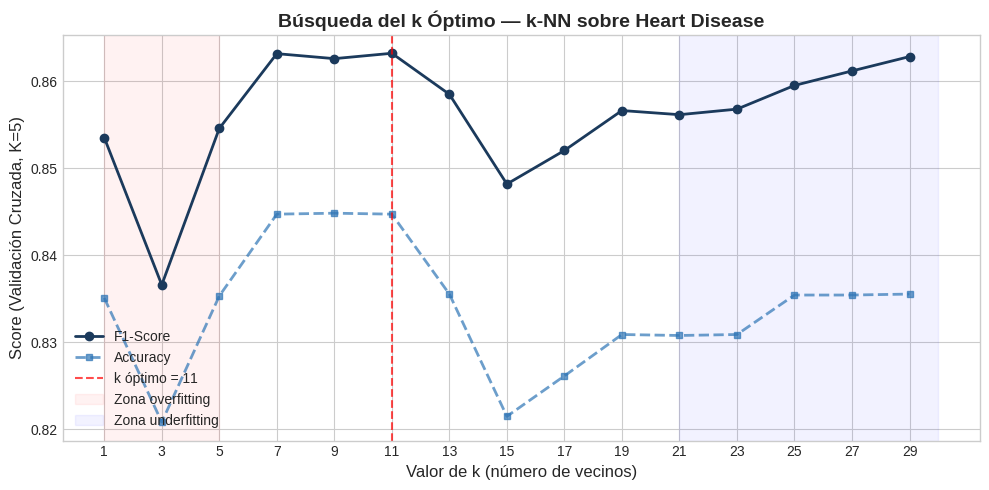


✅ Mejor k = 11  →  F1-Score = 0.8632


In [13]:
# Búsqueda del k óptimo con validación cruzada 5-Fold
k_range = range(1, 31, 2)  # Solo impares (evita empates en votación)
cv_scores_f1 = []
cv_scores_acc = []

print('Evaluando k-NN para cada valor de k...')
for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores_f1 = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='f1')
    scores_acc = cross_val_score(knn, X_train_scaled, y_train, cv=5, scoring='accuracy')
    cv_scores_f1.append(scores_f1.mean())
    cv_scores_acc.append(scores_acc.mean())
    print(f'  k={k:2d}: F1={scores_f1.mean():.4f} ± {scores_f1.std():.4f}  |  Acc={scores_acc.mean():.4f}')

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(list(k_range), cv_scores_f1, 'o-', color='#1B3A5C', lw=2, markersize=6, label='F1-Score')
ax.plot(list(k_range), cv_scores_acc, 's--', color='#2E75B6', lw=2, markersize=5, label='Accuracy', alpha=0.7)
best_k = list(k_range)[np.argmax(cv_scores_f1)]
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'k óptimo = {best_k}')

# Zonas de over/underfitting
ax.axvspan(1, 5, alpha=0.05, color='red', label='Zona overfitting')
ax.axvspan(21, 30, alpha=0.05, color='blue', label='Zona underfitting')

ax.set_xlabel('Valor de k (número de vecinos)', fontsize=12)
ax.set_ylabel('Score (Validación Cruzada, K=5)', fontsize=12)
ax.set_title('Búsqueda del k Óptimo — k-NN sobre Heart Disease', fontsize=14, fontweight='bold')
ax.legend(fontsize=10, loc='lower left')
ax.set_xticks(list(k_range))
plt.tight_layout()
plt.show()

print(f'\n✅ Mejor k = {best_k}  →  F1-Score = {max(cv_scores_f1):.4f}')

### Pregunta 4
**¿Cuál es el k óptimo encontrado? Observa el gráfico: ¿qué pasa en la zona roja (k pequeño, overfitting) y en la zona azul (k grande, underfitting)? ¿Dónde está el 'sweet spot'?**

**Respuesta:** El mejor valor encontrado fue **k = 11**, con F1 promedio de validación cruzada de **0.8632**. Con valores muy pequeños de k, el modelo puede sobreajustarse porque decide usando vecinos demasiado cercanos y sensibles al ruido. Con valores muy grandes, el modelo se suaviza demasiado y puede caer en underfitting. El punto razonable está alrededor de **k = 7 a k = 11**, donde el F1 se mantiene alto y estable.


---
## Paso 4.1: Mejora del modelo - Grid Search para k-NN

### Que haremos?
Hasta ahora probamos manualmente algunos valores de `k`: 1, 3, 5, ..., 29. Esa busqueda es util para entender el comportamiento del algoritmo, pero todavia es limitada.

Ahora usaremos **Grid Search**, que consiste en construir una **grilla de combinaciones de hiperparametros** y evaluar cada combinacion con validacion cruzada.

### Que hiperparametros buscaremos?
- `n_neighbors`: numero de vecinos. Ahora probaremos de 1 a 30, incluyendo valores pares como 20 y 30.
- `weights`: forma de ponderar vecinos. `uniform` da el mismo peso a todos; `distance` da mas peso a los vecinos mas cercanos.
- `metric`: distancia usada por k-NN. Compararemos `euclidean` y `manhattan`.

### Por que usamos Pipeline?
El `Pipeline` une la estandarizacion y el modelo en un solo flujo. Asi, en cada fold de validacion cruzada, el `StandardScaler` aprende solo con la parte de entrenamiento del fold. Esto evita pequenas fugas de informacion (**data leakage**) dentro de la validacion cruzada.

> Idea clave: Grid Search no adivina magicamente el mejor modelo; prueba sistematicamente combinaciones y elige la que mejor generaliza segun la metrica definida. En este laboratorio usaremos `F1-Score`, porque en diagnostico medico nos interesa equilibrar precision y recall.


In [ ]:
# ==========================================
# GRID SEARCH PARA k-NN
# ==========================================
# Pipeline: estandariza dentro de cada fold y luego entrena k-NN
pipe_knn = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier())
])

# Grilla de hiperparametros
# Nota: aqui si se prueban valores pares como 20 y 30.
param_grid_knn = {
    'knn__n_neighbors': list(range(1, 31)),
    'knn__weights': ['uniform', 'distance'],
    'knn__metric': ['euclidean', 'manhattan']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_knn = GridSearchCV(
    estimator=pipe_knn,
    param_grid=param_grid_knn,
    scoring='f1',
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

print('Ejecutando Grid Search para k-NN...')
grid_knn.fit(X_train, y_train)

print('\nMejores hiperparametros encontrados:')
print(grid_knn.best_params_)
print(f'Mejor F1 promedio en validacion cruzada: {grid_knn.best_score_:.4f}')

# Revisar las mejores combinaciones
results_knn = pd.DataFrame(grid_knn.cv_results_)
cols = ['param_knn__n_neighbors', 'param_knn__weights', 'param_knn__metric',
        'mean_test_score', 'std_test_score', 'mean_train_score']
top_knn = results_knn[cols].sort_values('mean_test_score', ascending=False).head(10)
top_knn_display = top_knn.rename(columns={
    'param_knn__n_neighbors': 'k',
    'param_knn__weights': 'weights',
    'param_knn__metric': 'metric',
    'mean_test_score': 'F1_CV',
    'std_test_score': 'Std_CV',
    'mean_train_score': 'F1_Train'
}).round(4)
print('\nTop 10 combinaciones segun F1 en validacion cruzada:')
try:
    display(top_knn_display)
except NameError:
    print(top_knn_display.to_string(index=False))

# Evaluacion final en test set con el mejor modelo de Grid Search
knn_grid_best = grid_knn.best_estimator_
y_pred_knn_grid = knn_grid_best.predict(X_test)
y_prob_knn_grid = knn_grid_best.predict_proba(X_test)[:, 1]

print('\n' + '=' * 60)
print('k-NN OPTIMIZADO CON GRID SEARCH - EVALUACION EN TEST SET')
print('=' * 60)
print(classification_report(y_test, y_pred_knn_grid, target_names=['Sano (0)', 'Enfermo (1)']))

auc_knn_grid = roc_auc_score(y_test, y_prob_knn_grid)
gini_knn_grid = 2 * auc_knn_grid - 1
cm_knn_grid = confusion_matrix(y_test, y_pred_knn_grid)

print(f'AUC-ROC: {auc_knn_grid:.4f}')
print(f'Gini:    {gini_knn_grid:.4f}')
print(f'FN (enfermos NO detectados): {cm_knn_grid[1,0]}')
print(f'FP (sanos mal diagnosticados): {cm_knn_grid[0,1]}')


### Pregunta 4.1
**Grid Search evaluo mas combinaciones que la busqueda manual. Que hiperparametros eligio como mejores (`k`, `weights`, `metric`)? El resultado mejora el F1 o reduce los Falsos Negativos frente al k-NN inicial? Explica por que ahora si se probaron valores pares de `k`.**

**Respuesta:** Grid Search eligió **k = 10**, **weights = distance** y **metric = manhattan**, con F1 promedio de validación cruzada de **0.8902**. En test, el k-NN optimizado obtuvo F1 de **0.8302** y **6 falsos negativos**, mientras que el k-NN base con k=11 obtuvo F1 de **0.8491** y **5 falsos negativos**. Es decir, Grid Search mejoró el F1 promedio en validación cruzada y el AUC en test, pero no redujo los FN frente al modelo base. Se pudieron probar valores pares porque con `weights='distance'` el voto no depende solo de contar vecinos, sino también de la distancia, reduciendo el problema de empates.


---
## 🔹 Paso 5: k-NN con k óptimo — Evaluación completa

### ¿Qué haremos?
Entrenaremos el modelo k-NN con el k óptimo y lo evaluaremos en el **test set** (datos que el modelo nunca ha visto).

### Métricas que calcularemos:
| Métrica | ¿Qué mide? | Rango |
|---|---|---|
| **Accuracy** | % de predicciones correctas (todas las clases) | 0–1 |
| **Precision** | De los que predije como enfermos, ¿cuántos lo son realmente? | 0–1 |
| **Recall** | De los enfermos reales, ¿cuántos detecté? | 0–1 |
| **F1-Score** | Balance entre Precision y Recall | 0–1 |
| **AUC-ROC** | Capacidad de discriminación global del modelo | 0.5–1.0 |
| **Gini** | 2×AUC−1. Poder discriminatorio normalizado | 0–1 |

*Ref: Gironés Roig, J. et al. (2017). Minería de datos. Editorial UOC. Cap. 10.*

In [15]:
# Entrenar k-NN con k óptimo
knn_best = KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train_scaled, y_train)
y_pred_knn = knn_best.predict(X_test_scaled)
y_prob_knn = knn_best.predict_proba(X_test_scaled)[:, 1]

print('=' * 55)
print(f'k-NN (k={best_k}) — EVALUACIÓN EN TEST SET')
print('=' * 55)
print(classification_report(y_test, y_pred_knn, target_names=['Sano (0)', 'Enfermo (1)']))

auc_knn = roc_auc_score(y_test, y_prob_knn)
gini_knn = 2 * auc_knn - 1
print(f'AUC-ROC: {auc_knn:.4f}  (>{0.7} = aceptable, >{0.8} = bueno)')
print(f'Gini:    {gini_knn:.4f}  (>{0.4} = bueno en la industria)')

# Matriz de confusión con interpretación
cm_knn = confusion_matrix(y_test, y_pred_knn)
print(f'\nMatriz de confusión:')
print(f'  VP (enfermos detectados):     {cm_knn[1,1]}')
print(f'  VN (sanos correctos):         {cm_knn[0,0]}')
print(f'  FP (sanos mal diagnosticados):{cm_knn[0,1]}')
print(f'  FN (enfermos NO detectados):  {cm_knn[1,0]}  ⚠️ Los más peligrosos')

k-NN (k=11) — EVALUACIÓN EN TEST SET
              precision    recall  f1-score   support

    Sano (0)       0.86      0.73      0.79        41
 Enfermo (1)       0.80      0.90      0.85        50

    accuracy                           0.82        91
   macro avg       0.83      0.82      0.82        91
weighted avg       0.83      0.82      0.82        91

AUC-ROC: 0.8654  (>0.7 = aceptable, >0.8 = bueno)
Gini:    0.7307  (>0.4 = bueno en la industria)

Matriz de confusión:
  VP (enfermos detectados):     45
  VN (sanos correctos):         30
  FP (sanos mal diagnosticados):11
  FN (enfermos NO detectados):  5  ⚠️ Los más peligrosos


### Pregunta 5
**¿Cuál es el F1-Score de k-NN para la clase 'Enfermo'? ¿Cuántos Falsos Negativos hay? En un hospital, cada FN es un paciente enfermo que se va a casa sin tratamiento. ¿Es aceptable este número?**

**Respuesta:** Para el k-NN base con **k=11**, el F1-score de la clase **Enfermo** fue **0.8491** y hubo **5 falsos negativos**. Aunque el número parece bajo, en un contexto hospitalario no es ideal porque cada FN significa un paciente enfermo no detectado. El modelo es una buena línea base, pero antes de usarlo en producción convendría ajustar el umbral o priorizar recall para reducir todavía más los FN.


---
## 🔹 Paso 6: Regresión Logística — Coeficientes y Odds Ratios

### ¿Qué haremos?
Entrenaremos una Regresión Logística y, además de evaluar métricas, **interpretaremos** qué variables influyen más en el riesgo de enfermedad.

### ¿Qué es un Odds Ratio?
El **Odds Ratio (OR)** indica cuánto cambia la probabilidad de enfermedad cuando una variable aumenta en 1 unidad:

| Valor del OR | Significado |
|---|---|
| **OR > 1** | La variable **AUMENTA** el riesgo de enfermedad |
| **OR = 1** | La variable **no tiene efecto** |
| **OR < 1** | La variable **DISMINUYE** el riesgo de enfermedad |

**Ejemplo clínico:** Si `exang` (angina por ejercicio) tiene OR = 2.3, significa que los pacientes con angina por ejercicio tienen **2.3 veces más probabilidad** de tener enfermedad cardíaca que los que no.

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

REGRESIÓN LOGÍSTICA — EVALUACIÓN EN TEST SET
              precision    recall  f1-score   support

    Sano (0)       0.76      0.68      0.72        41
 Enfermo (1)       0.76      0.82      0.79        50

    accuracy                           0.76        91
   macro avg       0.76      0.75      0.75        91
weighted avg       0.76      0.76      0.76        91

AUC-ROC: 0.8639
Gini:    0.7278

COEFICIENTES E INTERPRETACIÓN CLÍNICA
    Variable          β        OR  Interpretación clínica
----------------------------------------------------------------------
          cp    +1.0700    2.9154  ⬆️ AUMENTA riesgo (OR=2.92)
         sex    -0.7485    0.4731  ⬇️ DISMINUYE riesgo (OR=0.47)
     oldpeak    -0.6375    0.5286  ⬇️ DISMINUYE riesgo (OR=0.53)
          ca    -0.6229    0.5364  ⬇️ DISMINUYE riesgo (OR=0.54)
     thalach    +0.6227    1.8640  ⬆️ AUMENTA riesgo (OR=1.86)
        thal    -0.5968    0.5506  ⬇️ DISMINUYE riesgo (OR=0.55)
        chol    -0.4892    0.6131  ⬇️ DISM

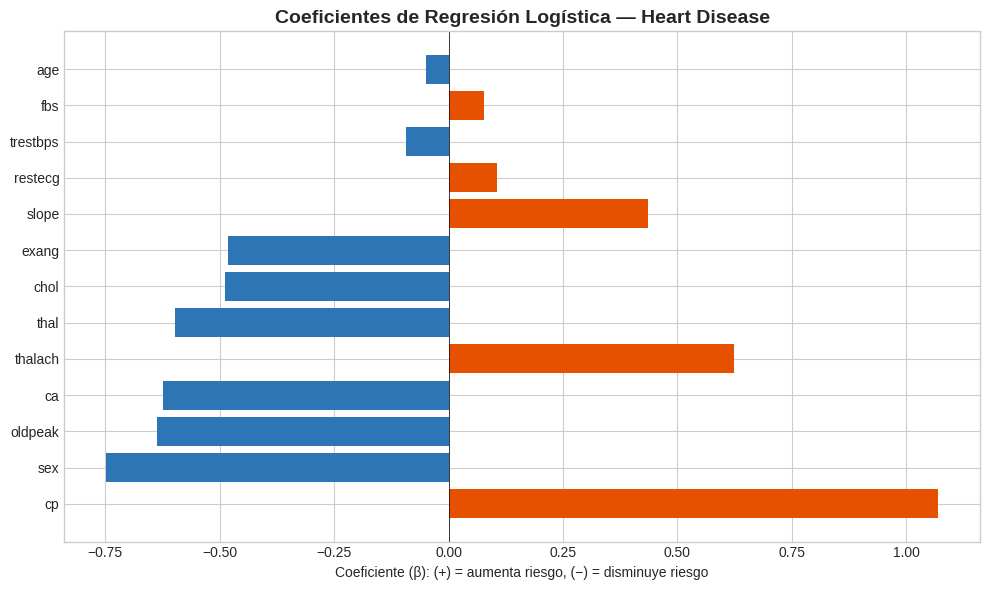

In [16]:
# Entrenar Regresión Logística
lr = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
y_prob_lr = lr.predict_proba(X_test_scaled)[:, 1]

print('=' * 55)
print('REGRESIÓN LOGÍSTICA — EVALUACIÓN EN TEST SET')
print('=' * 55)
print(classification_report(y_test, y_pred_lr, target_names=['Sano (0)', 'Enfermo (1)']))

auc_lr = roc_auc_score(y_test, y_prob_lr)
gini_lr = 2 * auc_lr - 1
print(f'AUC-ROC: {auc_lr:.4f}')
print(f'Gini:    {gini_lr:.4f}')

# ==========================================
# COEFICIENTES Y ODDS RATIOS
# ==========================================
print('\n' + '=' * 70)
print('COEFICIENTES E INTERPRETACIÓN CLÍNICA')
print('=' * 70)
print(f'{"Variable":>12s}  {"β":>9s}  {"OR":>8s}  Interpretación clínica')
print('-' * 70)

coefs = pd.DataFrame({'Variable': X.columns, 'Coeficiente': lr.coef_[0],
                       'Odds_Ratio': np.exp(lr.coef_[0])})
coefs = coefs.sort_values('Coeficiente', key=abs, ascending=False)

for _, row in coefs.iterrows():
    var = row['Variable']
    beta = row['Coeficiente']
    odds = row['Odds_Ratio']
    if beta > 0.1:
        interp = f'⬆️ AUMENTA riesgo (OR={odds:.2f})'
    elif beta < -0.1:
        interp = f'⬇️ DISMINUYE riesgo (OR={odds:.2f})'
    else:
        interp = f'↔️ Efecto pequeño (OR={odds:.2f})'
    print(f'{var:>12s}  {beta:+9.4f}  {odds:8.4f}  {interp}')

# Gráfico de coeficientes
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#E65100' if v > 0 else '#2E75B6' for v in coefs['Coeficiente']]
bars = ax.barh(coefs['Variable'], coefs['Coeficiente'], color=colors)
ax.set_title('Coeficientes de Regresión Logística — Heart Disease',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Coeficiente (β): (+) = aumenta riesgo, (−) = disminuye riesgo')
ax.axvline(x=0, color='black', linewidth=0.5)
plt.tight_layout()
plt.show()

### Pregunta 6
**¿Cuáles son las 3 variables con mayor coeficiente (en valor absoluto)? Clasifícalas: ¿cuáles AUMENTAN el riesgo (OR > 1) y cuáles lo DISMINUYEN (OR < 1)?**

**Respuesta:** Las 3 variables con mayor coeficiente absoluto fueron **`cp`**, **`sex`** y **`oldpeak`**. `cp` tuvo coeficiente positivo y **OR = 2.92**, por lo que aumenta el riesgo estimado. `sex` tuvo coeficiente negativo y **OR = 0.47**, por lo que disminuye el riesgo estimado según esta codificación. `oldpeak` también tuvo coeficiente negativo y **OR = 0.53**, por lo que reduce la probabilidad estimada de `target=1` en el modelo. Estos signos deben interpretarse junto con la codificación del dataset.


### Pregunta 7
**Si la variable `sex` tiene Odds Ratio = 1.8, escribe exactamente cómo se lo explicarías a un médico que no sabe estadística. Recuerda: sex=1 es masculino, sex=0 es femenino.**

**Respuesta:** Se lo explicaría así: “Manteniendo constantes las demás variables del modelo, los pacientes hombres (`sex=1`) tendrían **1.8 veces las odds** de presentar enfermedad cardíaca en comparación con las pacientes mujeres (`sex=0`)”. También aclararía que odds no es exactamente lo mismo que probabilidad directa, sino una razón de posibilidades usada por la regresión logística.


---
## 🔹 Paso 7: Comparación k-NN vs. Regresión Logística

### ¿Por qué comparar?
Ambos modelos resuelven el mismo problema pero de formas muy diferentes:

| Aspecto | k-NN (Lazy Learner) | Reg. Logística (Eager Learner) |
|---|---|---|
| **Entrenamiento** | No entrena, memoriza los datos | Aprende coeficientes β durante entrenamiento |
| **Predicción** | Lento: calcula distancias con TODOS los puntos | Rápido: solo aplica la fórmula σ(βX) |
| **Interpretabilidad** | Baja: no explica POR QUÉ clasifica | Alta: coeficientes y OR dan explicaciones |
| **Fronteras** | Complejas, no lineales | Lineales (separación recta) |
| **Normalización** | OBLIGATORIA | Recomendada |

*Ref: Burkov, A. (2019). The Hundred-Page Machine Learning Book. Cap. 3.*

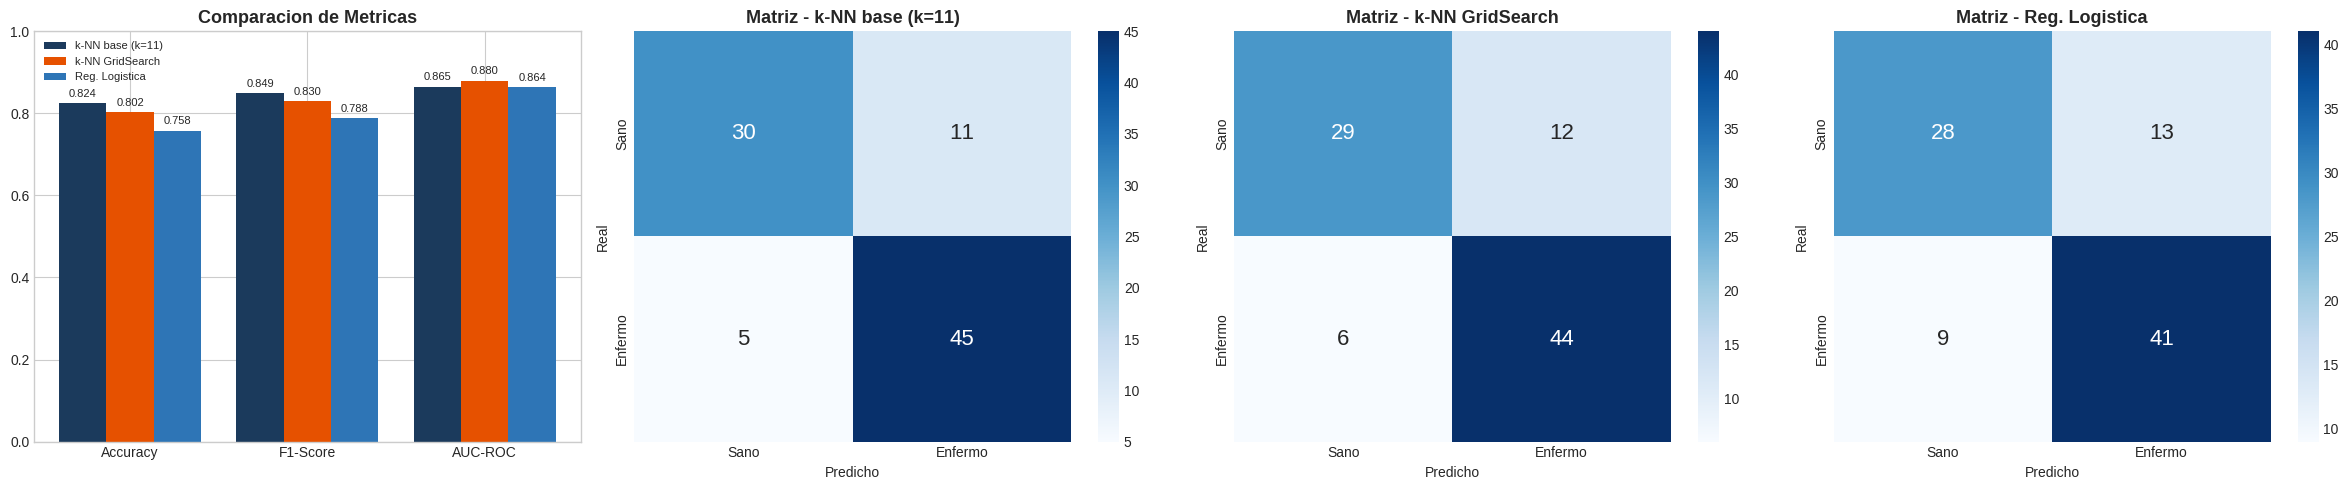


RESUMEN COMPARATIVO
                Modelo   Accuracy       F1   Recall      AUC    FN
------------------------------------------------------------------------------
      k-NN base (k=11)     0.8242   0.8491   0.9000   0.8654     5
       k-NN GridSearch     0.8022   0.8302   0.8800   0.8798     6
        Reg. Logistica     0.7582   0.7885   0.8200   0.8639     9


In [20]:
# ==========================================
# COMPARACION VISUAL COMPLETA
# ==========================================
models = {
    f'k-NN base (k={best_k})': (y_pred_knn, y_prob_knn),
    'k-NN GridSearch': (y_pred_knn_grid, y_prob_knn_grid),
    'Reg. Logistica': (y_pred_lr, y_prob_lr)
}

fig, axes = plt.subplots(1, len(models) + 1, figsize=(6 * (len(models) + 1), 5))

# 1. Barras de metricas
metrics_data = {}
for name, (pred, prob) in models.items():
    metrics_data[name] = {
        'Accuracy': accuracy_score(y_test, pred),
        'F1-Score': f1_score(y_test, pred),
        'AUC-ROC': roc_auc_score(y_test, prob)
    }

metric_names = ['Accuracy', 'F1-Score', 'AUC-ROC']
x = np.arange(len(metric_names))
width = 0.8 / len(models)
colors = ['#1B3A5C', '#E65100', '#2E75B6']

for idx, (name, values) in enumerate(metrics_data.items()):
    offset = (idx - (len(models) - 1) / 2) * width
    bars = axes[0].bar(x + offset, [values[m] for m in metric_names],
                       width, label=name, color=colors[idx % len(colors)])
    axes[0].bar_label(bars, fmt='%.3f', padding=3, fontsize=8)

axes[0].set_xticks(x)
axes[0].set_xticklabels(metric_names)
axes[0].set_ylim(0, 1)
axes[0].set_title('Comparacion de Metricas', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=8)

# Matrices de confusion
for i, (name, (pred, _)) in enumerate(models.items(), start=1):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Sano', 'Enfermo'], yticklabels=['Sano', 'Enfermo'],
                annot_kws={'size': 16})
    axes[i].set_title(f'Matriz - {name}', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Predicho')
    axes[i].set_ylabel('Real')

plt.tight_layout()
plt.show()

# Tabla resumen
print('\n' + '=' * 78)
print('RESUMEN COMPARATIVO')
print('=' * 78)
print(f'{"Modelo":>22s}  {"Accuracy":>9s}  {"F1":>7s}  {"Recall":>7s}  {"AUC":>7s}  {"FN":>4s}')
print('-' * 78)
for name, (pred, prob) in models.items():
    a = roc_auc_score(y_test, prob)
    cm = confusion_matrix(y_test, pred)
    print(f'{name:>22s}  {accuracy_score(y_test,pred):9.4f}  {f1_score(y_test,pred):7.4f}  '
          f'{recall_score(y_test,pred):7.4f}  {a:7.4f}  {cm[1,0]:4d}')


### Comentario comparativo de modelos

Aunque la Regresión Logística es más interpretable para explicar factores de riesgo, el k-NN base tuvo el mejor equilibrio operativo para este test: mayor F1, mayor recall y menos falsos negativos. En un hospital, esa reducción de FN pesa más que una pequeña diferencia de AUC.


### Pregunta 8
**¿Qué modelo tiene mejor F1-Score? ¿Y mejor AUC-ROC? Si las métricas no coinciden en señalar al mismo ganador, ¿cuál priorizarías para un diagnóstico médico y por qué?**

**Respuesta:** El mejor F1-score lo obtuvo **k-NN base (k=11)** con **0.8491**. El mejor AUC-ROC lo obtuvo **k-NN GridSearch** con **0.8798**. Como las métricas no coinciden completamente, para diagnóstico médico priorizaría primero **recall y falsos negativos**, porque es más grave no detectar a un paciente enfermo que enviar a un paciente sano a una evaluación adicional.


### Pregunta 9
**Compara los Falsos Negativos de ambos modelos (cuadrante inferior izquierdo de cada matriz). ¿Qué modelo tiene MENOS FN? ¿Por qué esto es lo MÁS IMPORTANTE en diagnóstico médico?**

**Respuesta:** El k-NN base tuvo **5 FN**, k-NN GridSearch tuvo **6 FN** y la Regresión Logística tuvo **9 FN**. El modelo con menos falsos negativos fue **k-NN base (k=11)**. Esto es lo más importante porque un FN representa un paciente realmente enfermo clasificado como sano, lo que podría retrasar tratamiento y aumentar el riesgo clínico.


---
## 🔹 Paso 8: Curvas ROC comparativas

### ¿Qué es la curva ROC?
Grafica la tasa de verdaderos positivos (TPR) contra la tasa de falsos positivos (FPR) para todos los umbrales posibles.
- **Cuanto más arriba y a la izquierda** la curva, mejor es el modelo.
- **La diagonal gris** representa un clasificador aleatorio (lanzar una moneda).
- **AUC** = área bajo la curva. AUC > 0.8 = modelo bueno.

*Ref: James, G. et al. (2023). An Introduction to Statistical Learning. Cap. 4.*

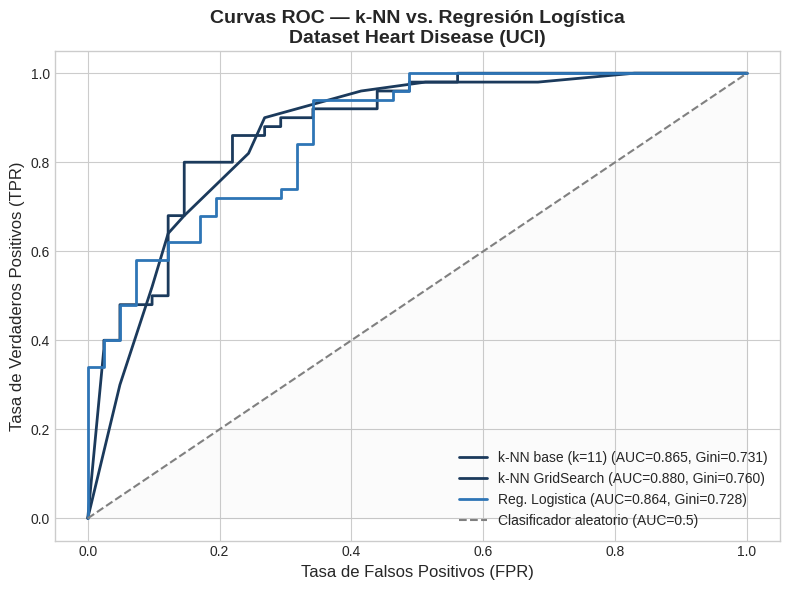


RESUMEN FINAL — HEART DISEASE CLASSIFICATION

📊 k-NN base (k=11):
   Accuracy:  0.8242
   F1-Score:  0.8491
   Precision: 0.8036
   Recall:    0.9000
   AUC-ROC:   0.8654
   Gini:      0.7307

📊 k-NN GridSearch:
   Accuracy:  0.8022
   F1-Score:  0.8302
   Precision: 0.7857
   Recall:    0.8800
   AUC-ROC:   0.8798
   Gini:      0.7595

📊 Reg. Logistica:
   Accuracy:  0.7582
   F1-Score:  0.7885
   Precision: 0.7593
   Recall:    0.8200
   AUC-ROC:   0.8639
   Gini:      0.7278


In [18]:
# Curvas ROC comparativas
fig, ax = plt.subplots(figsize=(8, 6))

for name, (_, prob) in models.items():
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    gini_val = 2 * auc_val - 1
    color = '#1B3A5C' if 'k-NN' in name else '#2E75B6'
    ax.plot(fpr, tpr, color=color, lw=2,
            label=f'{name} (AUC={auc_val:.3f}, Gini={gini_val:.3f})')

ax.plot([0,1],[0,1], color='gray', linestyle='--', label='Clasificador aleatorio (AUC=0.5)')
ax.fill_between([0,1],[0,1], alpha=0.03, color='gray')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12)
ax.set_title('Curvas ROC — k-NN vs. Regresión Logística\nDataset Heart Disease (UCI)',
             fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

# Resumen final
print('\n' + '=' * 60)
print('RESUMEN FINAL — HEART DISEASE CLASSIFICATION')
print('=' * 60)
for name, (pred, prob) in models.items():
    a = roc_auc_score(y_test, prob)
    print(f'\n📊 {name}:')
    print(f'   Accuracy:  {accuracy_score(y_test, pred):.4f}')
    print(f'   F1-Score:  {f1_score(y_test, pred):.4f}')
    print(f'   Precision: {precision_score(y_test, pred):.4f}')
    print(f'   Recall:    {recall_score(y_test, pred):.4f}')
    print(f'   AUC-ROC:   {a:.4f}')
    print(f'   Gini:      {2*a-1:.4f}')

### Pregunta 10
**Observando las curvas ROC: ¿qué modelo domina al otro en todos los umbrales? ¿Se cruzan las curvas en algún punto? Basándote en TODO lo analizado (métricas, interpretabilidad, FN), ¿cuál recomendarías al hospital?**

**Respuesta:** Las curvas son cercanas y el k-NN GridSearch tiene el AUC más alto (**0.8798**), pero eso no significa que sea el mejor en todos los criterios. El k-NN base tiene mejor F1 (**0.8491**), mejor recall (**0.9000**) y menos FN (**5**). Para el hospital recomendaría **k-NN base como modelo predictivo inicial**, acompañado de una explicación adicional con Regresión Logística para interpretar factores de riesgo clínicos.


---
# ACTIVIDAD 3: Caso de Estudio — Selección del Modelo para Diagnóstico Cardíaco

> **Contexto:** Un hospital quiere implementar un sistema de apoyo al diagnóstico de enfermedad cardíaca. El comité médico necesita tu recomendación técnica: ¿k-NN o Regresión Logística? Debes justificar tu decisión considerando rendimiento, interpretabilidad y el impacto clínico de los errores.

### Pregunta A
**¿Qué modelo recomendarías al hospital? Estructura tu respuesta en 3 ejes: (1) rendimiento (F1, AUC), (2) interpretabilidad para médicos (¿pueden entender por qué el modelo predice X?), (3) costo de cada tipo de error (FP = sano diagnosticado como enfermo → ansiedad y exámenes innecesarios; FN = enfermo no detectado → riesgo de muerte).**

**Respuesta:** Recomendaría **k-NN base (k=11)** como modelo predictivo inicial porque obtuvo el mejor F1 (**0.8491**), el mayor recall (**0.9000**) y el menor número de falsos negativos (**5**). Su AUC (**0.8654**) también es bueno. Sin embargo, k-NN es menos interpretable para médicos, por lo que usaría la Regresión Logística como apoyo explicativo para revisar factores de riesgo. En diagnóstico médico, el FN es el error más grave porque un paciente enfermo podría no recibir tratamiento; por eso priorizo recall y FN sobre accuracy.


### Pregunta B
**El médico jefe pregunta: '¿Qué factores de riesgo son los más importantes para la enfermedad cardíaca?' ¿Puedes responder esta pregunta con k-NN? ¿Y con Regresión Logística? Explica por qué uno de los dos modelos permite responder y el otro no.**

**Respuesta:** Con k-NN no es fácil responder directamente porque el modelo clasifica comparando pacientes cercanos y no entrega coeficientes globales por variable. Con Regresión Logística sí se puede responder mejor, porque cada variable tiene un coeficiente y un Odds Ratio. En este laboratorio, variables como `cp`, `sex`, `oldpeak`, `ca` y `thalach` aparecen con mayor peso en la predicción.


### Pregunta C
**En diagnóstico médico, ¿es peor un Falso Positivo (decirle a un sano que está enfermo) o un Falso Negativo (no detectar a un enfermo)? Si quisieras reducir los FN a costa de aumentar los FP, ¿qué parámetro del modelo ajustarías? (Pista: el umbral de clasificación, por defecto 0.5)**

**Respuesta:** Es peor un **Falso Negativo**, porque implica no detectar a un paciente enfermo. Un Falso Positivo puede generar ansiedad y exámenes adicionales, pero un FN puede retrasar un tratamiento necesario. Para reducir FN bajaría el **umbral de clasificación** por debajo de 0.5, de modo que el modelo clasifique más pacientes como enfermos y aumente el recall, aceptando más FP.


### Pregunta D
**Compara los dos datasets que hemos usado en el curso: Heart Disease (303 pacientes, 13 variables numéricas) vs. Telco Churn (7,043 clientes, variables mixtas). ¿En cuál de los dos k-NN tiene más desventaja computacional? ¿Por qué Heart Disease no necesitó One-Hot Encoding mientras que Telco Churn sí?**

**Respuesta:** k-NN tiene más desventaja computacional en **Telco Churn**, porque hay muchos más registros y más variables después de codificar categorías. k-NN debe calcular distancias contra muchos puntos, por lo que crece en costo cuando aumenta el tamaño del dataset. Heart Disease no necesitó One-Hot Encoding porque sus variables ya estaban codificadas numéricamente; Telco sí lo necesitó porque tenía variables categóricas de texto como contrato, método de pago y servicios.


### Pregunta E
**Propón 3 mejoras concretas y específicas para mejorar el rendimiento de los modelos en este dataset. Para cada mejora, explica qué problema resuelve. (Ejemplos: feature engineering clínico, regularización, SMOTE, selección de variables, ensembles, etc.)**

**Respuesta:**

1. **Ajustar el umbral de clasificación:** permitiría reducir falsos negativos aumentando el recall, importante en diagnóstico médico.
2. **Crear variables clínicas derivadas:** por ejemplo grupos de edad, presión arterial alta o combinaciones entre dolor de pecho y frecuencia cardíaca. Esto puede capturar patrones médicos no lineales.
3. **Probar modelos ensemble:** Random Forest, Gradient Boosting o XGBoost podrían capturar interacciones complejas y mejorar la estabilidad frente al tamaño pequeño del dataset.


---
# CONCLUSIONES

1. El dataset Heart Disease está relativamente balanceado: 54.5% de pacientes enfermos y 45.5% sanos, por lo que el problema no tiene el mismo nivel de desbalance que Telco Churn.

2. El k-NN base con k=11 fue el mejor modelo para reducir falsos negativos en este test: obtuvo F1 de 0.8491, recall de 0.9000 y solo 5 pacientes enfermos no detectados.

3. La Regresión Logística fue menos fuerte en métricas, pero aporta interpretabilidad mediante coeficientes y Odds Ratios, lo que es valioso para explicar factores de riesgo a médicos.


---
### 📚 Referencias bibliográficas
- Burkov, A. (2019). *The Hundred-Page Machine Learning Book*. Andriy Burkov.
- Géron, A. (2022). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.
- Gironés Roig, J., Casas Roma, J., Minguillón Alfonso, J. y Caihuelas Quiles, R. (2017). *Minería de datos: modelos y algoritmos*. Editorial UOC.
- James, G., Witten, D., Hastie, T. y Tibshirani, R. (2023). *An Introduction to Statistical Learning* (2.ª ed.). Springer.

---
*Minería de Datos — Semana 6 | TECSUP 2026-I | Prof. Pilar Rocío Sayán Mejía*